# Saliency Map Generation for MEG Phoneme Classification

This notebook demonstrates:
1. Loading a trained Conformer model from checkpoint
2. Evaluating the model on the validation set
3. Generating saliency maps to visualize which MEG sensors/timepoints contribute most to predictions
4. Visualizing saliency maps for multiple input samples

## 1. Import Libraries

In [1]:
import os
import yaml
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import pytorch_lightning as lightning
from tqdm import tqdm
from torchmetrics import Accuracy, F1Score

from libribrain_experiments.utils import get_datasets_from_config
from libribrain_experiments.models.configurable_modules.classification_module import ClassificationModule

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Skipping import of cpp extensions due to incompatible torch version 2.9.1+cu128 for torchao version 0.14.1             Please see https://github.com/pytorch/ao/issues/2919 for more info


PyTorch version: 2.9.1+cu128
CUDA available: True


## 2. Load Model

### Load Configuration and Setup

In [2]:
# Load configuration
config_path = 'configs/phoneme/conformer/custom-2025-09-09-config.yaml'
checkpoint_path = 'out/final-results/best-val_f1_macro-conformer-custom-2025-09-09-hpo-0-epoch=26-val_f1_macro=0.6409.ckpt'

with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

# Set seed for reproducibility
seed = config["general"]["seed"]
lightning.seed_everything(seed)

print(f"Config loaded from: {config_path}")
print(f"Seed: {seed}")

Seed set to 42


Config loaded from: configs/phoneme/conformer/custom-2025-09-09-config.yaml
Seed: 42


### Load Trained Model

In [3]:
# Load model from checkpoint
print(f"Loading model from: {checkpoint_path}")
model = ClassificationModule.load_from_checkpoint(checkpoint_path)
model.eval()

# Move to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

print(f"Model loaded successfully on {device}")
print(f"Model architecture: {model.modules_list[0].__class__.__name__}")

Loading model from: out/final-results/best-val_f1_macro-conformer-custom-2025-09-09-hpo-0-epoch=26-val_f1_macro=0.6409.ckpt
Model loaded successfully on cuda
Model architecture: ConformerSpeech


### Prepare Validation Dataset

In [4]:
from copy import deepcopy

config_copy = deepcopy(config)

del config_copy['data']['general']['dynamic_averaged_samples']
# del config_copy['data']['general']['averaged_samples']
config_copy['data']['general']['averaged_samples'] = 50
del config_copy['data']['datasets']['train']

In [5]:
# Load datasets
_, val_dataset, test_dataset, labels = get_datasets_from_config(
    config_copy["data"], seed
)

print(f"Validation dataset size: {len(val_dataset)}")
print(f"Number of phoneme classes: {len(labels)}")
print(f"Phoneme labels: {labels[:10]}... (showing first 10)")

# Create validation dataloader
val_loader = DataLoader(
    val_dataset, 
    batch_size=1,
    num_workers=config["data"]["dataloader"]["num_workers"],
    shuffle=False
)

# Inspect a sample
sample_x, sample_y = next(iter(val_loader))
print(f"\nSample input shape: {sample_x.shape}")  # (batch, sensors, time)
print(f"Sample label shape: {sample_y.shape}")
print(f"Input range: [{sample_x.min():.3f}, {sample_x.max():.3f}]")

100%|██████████| 12051/12051 [00:01<00:00, 7807.77it/s]

Validation dataset size: 247
Number of phoneme classes: 39
Phoneme labels: ['aa', 'ae', 'ah', 'ao', 'aw', 'ay', 'b', 'ch', 'd', 'dh']... (showing first 10)



Sample input shape: torch.Size([1, 306, 125])
Sample label shape: torch.Size([1])
Input range: [-0.476, 0.496]


## 3. Evaluate Model on Validation Set

In [6]:
# Evaluate model on validation set
num_classes = len(labels)
accuracy = Accuracy(task="multiclass", num_classes=num_classes).to(device)
f1_macro = F1Score(task="multiclass", num_classes=num_classes, average="macro").to(device)
f1_micro = F1Score(task="multiclass", num_classes=num_classes, average="micro").to(device)

all_preds = []
all_targets = []

print("Evaluating model on validation set...")
with torch.no_grad():
    for batch_idx, (x, y) in tqdm(enumerate(val_loader), total=len(val_loader)):
        x = x.to(device)
        y = y.to(device)
        
        # Forward pass
        outputs = model(x)
        preds = torch.argmax(outputs, dim=1)
        
        # Update metrics
        accuracy.update(preds, y)
        f1_macro.update(preds, y)
        f1_micro.update(preds, y)
        
        all_preds.append(preds.cpu())
        all_targets.append(y.cpu())
        
# Compute final metrics
final_accuracy = accuracy.compute()
final_f1_macro = f1_macro.compute()
final_f1_micro = f1_micro.compute()

print(f"\n{'='*50}")
print(f"Validation Set Performance:")
print(f"{'='*50}")
print(f"Accuracy:  {final_accuracy:.4f}")
print(f"F1-Macro:  {final_f1_macro:.4f}")
print(f"F1-Micro:  {final_f1_micro:.4f}")
print(f"{'='*50}")

Evaluating model on validation set...


100%|██████████| 247/247 [00:01<00:00, 176.60it/s]


Validation Set Performance:
Accuracy:  0.5101
F1-Macro:  0.4306
F1-Micro:  0.5101


## 4. Saliency Map Function

In [7]:
def generate_saliency_map(model, input_data, target_class=None):
    """
    Generate saliency map for a single input sample.
    
    Args:
        model: Trained classification model
        input_data: Input tensor of shape (sensors, time) or (1, sensors, time)
        target_class: Class index to compute gradients for. If None, uses predicted class.
    
    Returns:
        saliency: Gradient magnitudes of shape (sensors, time)
        predicted_class: Index of predicted class
        target_class: Index of target class used for gradients
    """
    # Ensure input has batch dimension
    if input_data.dim() == 2:
        input_data = input_data.unsqueeze(0)  # (1, sensors, time)
    
    # Move to device and enable gradients
    input_data = input_data.to(device).detach()
    input_data.requires_grad = True
    
    # Forward pass
    model.eval()
    output = model(input_data)
    
    # Get predicted class
    predicted_class = torch.argmax(output, dim=1).item()
    
    # Use predicted class if target not specified
    if target_class is None:
        target_class = predicted_class
    
    # Compute gradients with respect to input for target class
    model.zero_grad()
    output[0, target_class].backward()
    
    # Get gradient magnitudes
    saliency = input_data.grad.abs().squeeze(0)  # (sensors, time)
    
    return saliency.cpu().detach(), predicted_class, target_class


In [8]:
def plot_saliency_map(saliency, true_label=None, pred_label=None, target_label=None, 
                      labels_list=None, title=None, axes=None):
    """
    Plot saliency map as a heatmap.
    
    Args:
        saliency: Gradient magnitudes of shape (sensors, time)
        true_label: True class index
        pred_label: Predicted class index
        target_label: Target class used for saliency
        labels_list: List of class names
        title: Custom title for plot
    """
    if axes is None:
        fig, ax = plt.subplots(figsize=(14, 8))
    else:
        fig = None
        ax = axes
    
    # Plot heatmap
    im = ax.imshow(saliency.numpy(), aspect='auto', cmap='hot', interpolation='nearest')
    
    # Labels and title
    ax.set_xlabel('Time (samples)', fontsize=12)
    ax.set_ylabel('MEG Sensors', fontsize=12)
    
    if title is None:
        title = "Saliency Map"
        if labels_list is not None and pred_label is not None:
            title += f"\nPredicted: {labels_list[pred_label]}"
            if true_label is not None and true_label != pred_label:
                title += f" | True: {labels_list[true_label]}"
            if target_label is not None and target_label != pred_label:
                title += f" | Target: {labels_list[target_label]}"
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    
    # Colorbar
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Gradient Magnitude', rotation=270, labelpad=20)
    
    # Add time axis in seconds
    time_samples = saliency.shape[1]
    time_sec = time_samples / 250  # 250 Hz sampling rate
    ax.set_xticks(np.linspace(0, time_samples-1, 6))
    ax.set_xticklabels([f'{t:.2f}s' for t in np.linspace(0, time_sec, 6)])
    
    plt.tight_layout()

    return fig, ax

In [9]:
def sample_and_visualize_saliency(dataset, model, sample_idx, labels_list=None, axes=None):
    """
    Sample data from dataset and generate saliency map visualization.
    
    Args:
        dataset: Validation dataset
        model: Trained model
        sample_idx: Index of sample to visualize
        labels_list: List of phoneme labels
    
    Returns:
        saliency, true_label, pred_label
    """
    # Get sample
    x, y = dataset[sample_idx]
    x_tensor = torch.from_numpy(x).float() if isinstance(x, np.ndarray) else x
    
    # Generate saliency map
    saliency, pred_label, target_label = generate_saliency_map(model, x_tensor)
    
    # Plot
    plot_saliency_map(
        saliency, 
        true_label=y.item() if torch.is_tensor(y) else y,
        pred_label=pred_label,
        target_label=target_label,
        labels_list=labels_list,
        axes=axes
    )
    # plt.show()
    
    return saliency, y, pred_label

## 5. Generate Saliency Map

### Single Sample

Generating saliency map for sample 100...
True label: z
Predicted label: t
Correct: False
Saliency range: [0.000000, 3.395918]


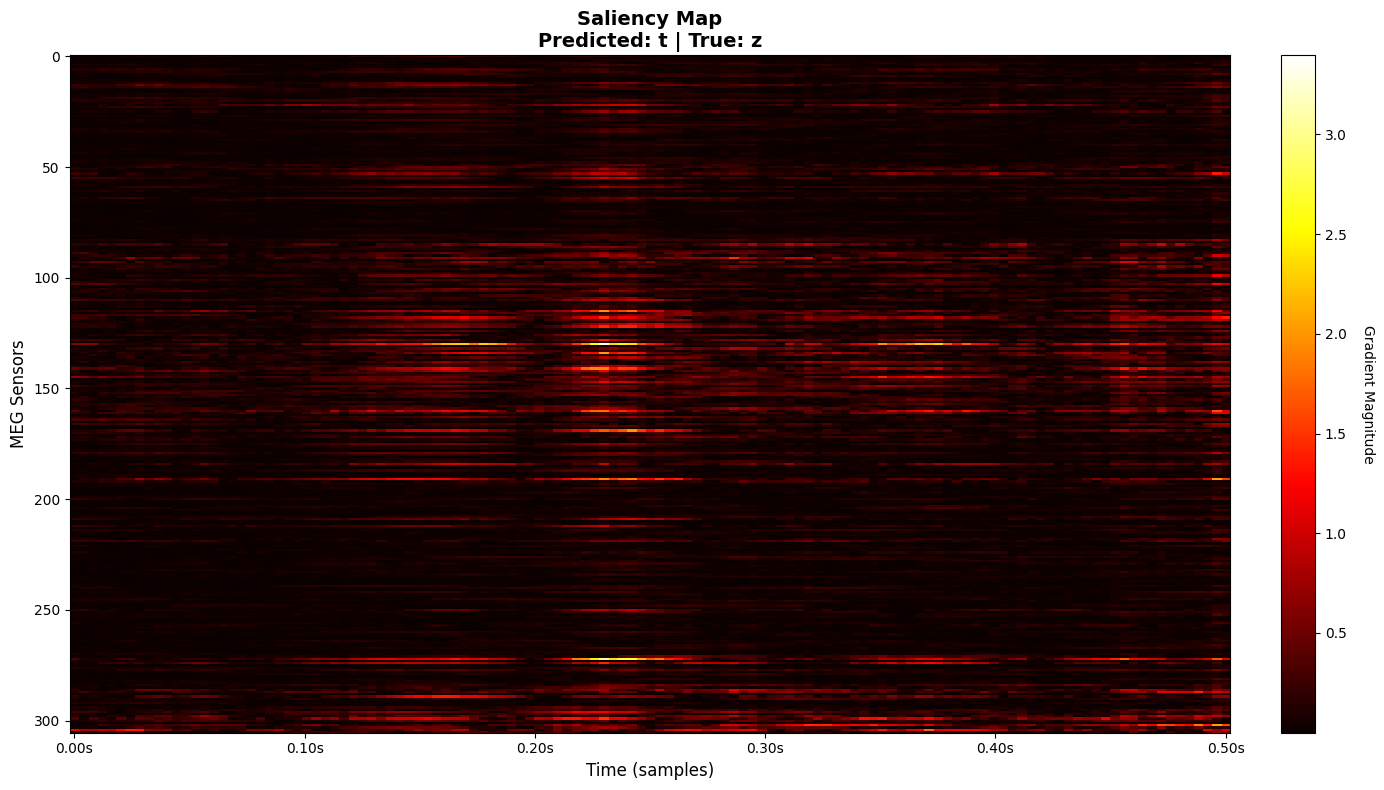

In [10]:
# Visualize saliency map for a single sample
sample_idx = 100

print(f"Generating saliency map for sample {sample_idx}...")
saliency, true_label, pred_label = sample_and_visualize_saliency(
    val_dataset, model, sample_idx, labels_list=labels
)

true_label_val = true_label.item() if torch.is_tensor(true_label) else true_label
print(f"True label: {labels[true_label_val]}")
print(f"Predicted label: {labels[pred_label]}")
print(f"Correct: {true_label_val == pred_label}")
print(f"Saliency range: [{saliency.min():.6f}, {saliency.max():.6f}]")

### Multiple Samples

Generating saliency maps for 6 samples...
Sample indices: [5, 15, 30, 45, 60, 80]



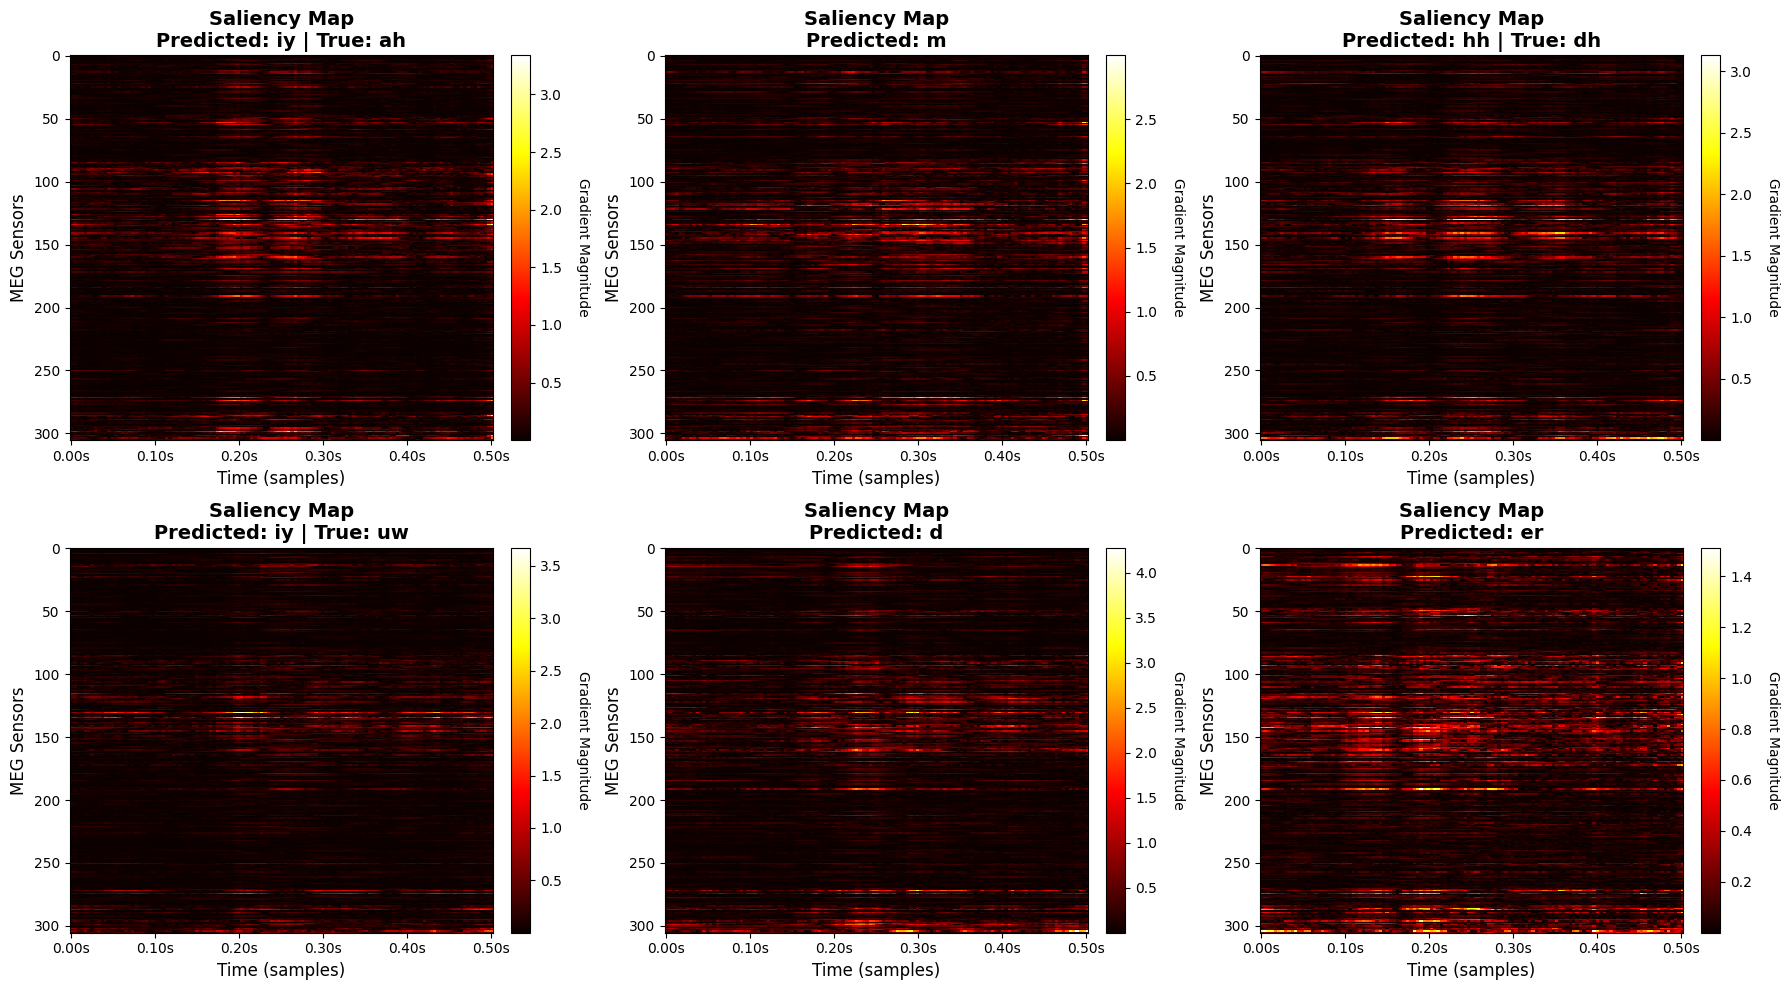

In [11]:
# Generate saliency maps for multiple different samples
sample_indices = [5, 15, 30, 45, 60, 80]

print(f"Generating saliency maps for {len(sample_indices)} samples...")
print(f"Sample indices: {sample_indices}\n")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, idx in enumerate(sample_indices):
    saliency, true_label, pred_label = sample_and_visualize_saliency(
        val_dataset, model, idx, labels_list=labels, axes=axes[i]
    )

fig.tight_layout()
plt.show()

## 6. Analyze Saliency Patterns

### Whole Validation Set

In [ ]:
# Aggregate saliency maps across multiple samples
# n_samples = 100
# sample_indices_analysis = np.random.choice(len(val_dataset), n_samples, replace=False)
n_samples = len(val_dataset)
sample_indices_analysis = np.arange(len(val_dataset))

print(f"Analyzing saliency patterns across {len(sample_indices_analysis)} samples...")

all_saliencies = []
for idx in tqdm(sample_indices_analysis):
    x, y = val_dataset[idx]
    x_tensor = torch.from_numpy(x).float() if isinstance(x, np.ndarray) else x
    saliency, _, _ = generate_saliency_map(model, x_tensor)
    all_saliencies.append(saliency.numpy())

# Stack and compute mean saliency
all_saliencies = np.stack(all_saliencies)
mean_saliency = all_saliencies.mean(axis=0)

# Plot mean saliency map
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Mean saliency heatmap
im1 = axes[0].imshow(mean_saliency, aspect='auto', cmap='hot', interpolation='nearest')
axes[0].set_xlabel('Time (samples)', fontsize=12)
axes[0].set_ylabel('MEG Sensors', fontsize=12)
axes[0].set_title(f'Mean Saliency Map (n={n_samples})', fontsize=14, fontweight='bold')
plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

# Time axis
time_samples = mean_saliency.shape[1]
time_sec = time_samples / 250
axes[0].set_xticks(np.linspace(0, time_samples-1, 6))
axes[0].set_xticklabels([f'{t:.2f}s' for t in np.linspace(0, time_sec, 6)])

# Sensor importance (mean over time)
sensor_importance = mean_saliency.mean(axis=1)
axes[1].barh(range(len(sensor_importance)), sensor_importance)
axes[1].set_ylabel('Sensor Index', fontsize=12)
axes[1].set_xlabel('Mean Gradient Magnitude', fontsize=12)
axes[1].set_title('Sensor Importance', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# Temporal importance (mean over sensors)
temporal_importance = mean_saliency.mean(axis=0)
fig, ax = plt.subplots(figsize=(14, 4))
time_axis = np.linspace(0, time_sec, len(temporal_importance))
ax.plot(time_axis, temporal_importance, linewidth=2)
ax.fill_between(time_axis, temporal_importance, alpha=0.3)
ax.set_xlabel('Time (seconds)', fontsize=12)
ax.set_ylabel('Mean Gradient Magnitude', fontsize=12)
ax.set_title('Temporal Importance Pattern', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nTemporal pattern: Peak importance at {time_axis[temporal_importance.argmax()]:.3f}s")

Analyzing saliency patterns across 247 samples...


100%|██████████| 247/247 [00:09<00:00, 25.19it/s]


### Group Saliency by Phoneme Label

In [ ]:
# Group saliencies by predicted and true labels
print("Grouping saliency maps by phoneme labels...")

saliency_by_true_label = {i: [] for i in range(len(labels))}
saliency_by_pred_label = {i: [] for i in range(len(labels))}

for idx in tqdm(range(len(val_dataset)), desc="Processing samples"):
    x, y = val_dataset[idx]
    x_tensor = torch.from_numpy(x).float() if isinstance(x, np.ndarray) else x
    saliency, pred_label, _ = generate_saliency_map(model, x_tensor)
    
    true_label_val = y.item() if torch.is_tensor(y) else y
    
    saliency_by_true_label[true_label_val].append(saliency.numpy())
    saliency_by_pred_label[pred_label].append(saliency.numpy())

# Compute mean saliency for each label
mean_saliency_by_true = {}
mean_saliency_by_pred = {}

for label_idx in range(len(labels)):
    if len(saliency_by_true_label[label_idx]) > 0:
        mean_saliency_by_true[label_idx] = np.stack(saliency_by_true_label[label_idx]).mean(axis=0)
    else:
        mean_saliency_by_true[label_idx] = np.zeros_like(mean_saliency)
        
    if len(saliency_by_pred_label[label_idx]) > 0:
        mean_saliency_by_pred[label_idx] = np.stack(saliency_by_pred_label[label_idx]).mean(axis=0)
    else:
        mean_saliency_by_pred[label_idx] = np.zeros_like(mean_saliency)

print(f"\nGrouped saliency maps by {len(labels)} phoneme classes")

### Each Sample

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

# Create interactive visualization with dropdown for phoneme and label type
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Mean Saliency Heatmap', 'Sensor Importance'),
    column_widths=[0.65, 0.35],
    specs=[[{"type": "heatmap"}, {"type": "bar"}]]
)

# Prepare data for all phonemes and label types
time_samples = mean_saliency.shape[1]
time_sec = time_samples / 250
time_axis_plotly = np.linspace(0, time_sec, time_samples)

# Create traces for each phoneme and label type
traces_heatmap = []
traces_bar = []

for label_type in ['True Label', 'Predicted Label']:
    mean_dict = mean_saliency_by_true if label_type == 'True Label' else mean_saliency_by_pred
    
    for label_idx in range(len(labels)):
        saliency_data = mean_dict[label_idx]
        sensor_importance_data = saliency_data.mean(axis=1)
        
        # Heatmap trace
        trace_heatmap = go.Heatmap(
            z=saliency_data,
            x=time_axis_plotly,
            y=np.arange(saliency_data.shape[0]),
            colorscale='Hot',
            name=f'{labels[label_idx]} ({label_type})',
            visible=False,
            colorbar=dict(x=0.62, len=0.9, title='Gradient<br>Magnitude')
        )
        traces_heatmap.append(trace_heatmap)
        
        # Bar trace
        trace_bar = go.Bar(
            x=sensor_importance_data,
            y=np.arange(len(sensor_importance_data)),
            orientation='h',
            name=f'{labels[label_idx]} ({label_type})',
            visible=False,
            marker=dict(color='darkred')
        )
        traces_bar.append(trace_bar)

# Make first phoneme visible
traces_heatmap[0].visible = True
traces_bar[0].visible = True

# Add traces to figure
for trace in traces_heatmap:
    fig.add_trace(trace, row=1, col=1)
for trace in traces_bar:
    fig.add_trace(trace, row=1, col=2)

# Create dropdown menu
dropdown_buttons = []

for i, label_type in enumerate(['True Label', 'Predicted Label']):
    for j, label_idx in enumerate(range(len(labels))):
        idx = i * len(labels) + j
        
        # Create visibility array
        visible = [False] * (len(traces_heatmap) + len(traces_bar))
        visible[idx] = True  # heatmap
        visible[len(traces_heatmap) + idx] = True  # bar
        
        count = len(saliency_by_true_label[label_idx]) if label_type == 'True Label' else len(saliency_by_pred_label[label_idx])
        
        dropdown_buttons.append(
            dict(
                label=f'{labels[label_idx]} ({label_type}, n={count})',
                method='update',
                args=[
                    {'visible': visible},
                    {'title.text': f'Mean Saliency for Phoneme: {labels[label_idx]} ({label_type})<br>n={count} samples'}
                ]
            )
        )

# Update layout
fig.update_layout(
    title=f'Mean Saliency for Phoneme: {labels[0]} (True Label)<br>n={len(saliency_by_true_label[0])} samples',
    height=600,
    showlegend=False,
    updatemenus=[
        dict(
            buttons=dropdown_buttons,
            direction='down',
            pad={'r': 10, 't': 10},
            showactive=True,
            x=0.01,
            xanchor='left',
            y=1.15,
            yanchor='top'
        )
    ]
)

# Update axes
fig.update_xaxes(title_text='Time (seconds)', row=1, col=1)
fig.update_yaxes(title_text='MEG Sensors', row=1, col=1, autorange='reversed')
fig.update_xaxes(title_text='Mean Gradient Magnitude', row=1, col=2)
fig.update_yaxes(title_text='Sensor Index', row=1, col=2, autorange='reversed')

fig.show()

print("Interactive phoneme-specific saliency visualization created!")

## 12. Interactive Sample Browser with Slider

Browse through individual samples with an interactive slider to explore saliency maps.

In [ ]:
# Prepare data for all samples (or subset for performance)
max_samples_to_show = min(500, len(val_dataset))  # Limit for performance
print(f"Preparing interactive sample browser for {max_samples_to_show} samples...")

# Pre-compute saliency maps for all samples
sample_data = []
for idx in tqdm(range(max_samples_to_show), desc="Computing saliency maps"):
    x, y = val_dataset[idx]
    x_tensor = torch.from_numpy(x).float() if isinstance(x, np.ndarray) else x
    saliency, pred_label, _ = generate_saliency_map(model, x_tensor)
    
    true_label_val = y.item() if torch.is_tensor(y) else y
    
    sample_data.append({
        'idx': idx,
        'saliency': saliency.numpy(),
        'true_label': true_label_val,
        'pred_label': pred_label
    })

print("Creating interactive sample browser...")

# Create figure with slider
fig = go.Figure()

# Add frames for each sample
frames = []
for i, data in enumerate(sample_data):
    true_label = data['true_label']
    pred_label = data['pred_label']
    match_symbol = '✓' if true_label == pred_label else '✗'
    
    frame = go.Frame(
        data=[go.Heatmap(
            z=data['saliency'],
            x=time_axis_plotly,
            y=np.arange(data['saliency'].shape[0]),
            colorscale='Hot',
            colorbar=dict(title='Gradient<br>Magnitude')
        )],
        name=str(i),
        layout=go.Layout(
            title=f"Sample {data['idx']} | True: {labels[true_label]} | Predicted: {labels[pred_label]} {match_symbol}"
        )
    )
    frames.append(frame)

# Add initial data
fig.add_trace(go.Heatmap(
    z=sample_data[0]['saliency'],
    x=time_axis_plotly,
    y=np.arange(sample_data[0]['saliency'].shape[0]),
    colorscale='Hot',
    colorbar=dict(title='Gradient<br>Magnitude')
))

# Update layout with slider
fig.update_layout(
    title=f"Sample {sample_data[0]['idx']} | True: {labels[sample_data[0]['true_label']]} | Predicted: {labels[sample_data[0]['pred_label']]}",
    xaxis_title='Time (seconds)',
    yaxis_title='MEG Sensors',
    height=700,
    sliders=[{
        'active': 0,
        'yanchor': 'top',
        'y': -0.05,
        'xanchor': 'left',
        'currentvalue': {
            'prefix': 'Sample Index: ',
            'visible': True,
            'xanchor': 'right'
        },
        'pad': {'b': 10, 't': 0},
        'len': 0.9,
        'x': 0.05,
        'steps': [
            {
                'args': [[frame.name], {
                    'frame': {'duration': 0, 'redraw': True},
                    'mode': 'immediate',
                    'transition': {'duration': 0}
                }],
                'label': str(i),
                'method': 'animate'
            }
            for i, frame in enumerate(frames)
        ]
    }]
)

# Add frames to figure
fig.frames = frames

# Reverse y-axis to match convention
fig.update_yaxes(autorange='reversed')

fig.show()